# Teacher Model — Detección de Identificador

Entrena el modelo **Teacher** (CNN grande) que luego guiará al Student via Knowledge Distillation.

### Splits del dataset

| Split | easy | medium | hard | other |
|-------|------|--------|------|-------|
| Train | 90%  | 90%    | 70%  | 0%    |
| Val   | 10%  | 10%    | 25%  | 0%    |
| Test  | 0%   | 0%     | 5%   | 100%  |

### Clases
- `0` Ausente
- `1` Izquierda
- `2` Centro
- `3` Derecha

In [7]:
import os, sys
from pathlib import Path

# Exponer libs CUDA del venv al linker dinámico
_nvidia = Path(sys.executable).parent.parent / 'lib' / 'python3.12' / 'site-packages' / 'nvidia'
_paths  = [str(p) for p in _nvidia.glob('*/lib') if p.is_dir()]
_paths.append('/usr/lib/wsl/lib')
os.environ['LD_LIBRARY_PATH'] = ':'.join(_paths + [os.environ.get('LD_LIBRARY_PATH', '')])

## 1. Imports y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

DATASET_DIR = Path('.')  # ejecutar desde Lab_3/Extra_1/
CLASS_NAMES = ['Ausente', 'Izquierda', 'Centro', 'Derecha']
NUM_CLASSES = 4
IMG_SIZE    = 128
BATCH_SIZE  = 32
SEED        = 42

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1780358336.263284  210505 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780358336.304276  210505 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780358337.112267  210505 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga y separación del dataset

El shuffle es determinista (seed fija) para que teacher y student usen exactamente el mismo split.

In [2]:
def load_subset(difficulty: str, frac_start: float, frac_end: float) -> tuple:
    d = DATASET_DIR / difficulty
    entries = []
    with open(d / 'tags.txt') as f:
        for line in f:
            line = line.strip()
            if line:
                fname, label = line.split(',')
                entries.append((d / fname, int(label)))
    rng = np.random.default_rng(seed=SEED)
    entries = [entries[i] for i in rng.permutation(len(entries))]
    n = len(entries)
    entries = entries[int(frac_start * n) : int(frac_end * n)]
    X = np.array([
        np.array(Image.open(p).convert('L'), dtype=np.float32)[..., np.newaxis] / 255.0
        for p, _ in entries
    ])
    y = np.array([lbl for _, lbl in entries], dtype=np.int32)
    return X, y

def concat_splits(specs):
    parts = [load_subset(d, s, e) for d, s, e in specs]
    return np.concatenate([p[0] for p in parts]), np.concatenate([p[1] for p in parts])

# ----- Porciones de training (se balancean después) -----
X_easy_raw, y_easy_raw = load_subset('easy',   0.00, 0.80)  # 80% train
X_med_raw,  y_med_raw  = load_subset('medium', 0.00, 0.80)  # 80% train
X_hard_raw, y_hard_raw = load_subset('hard',   0.00, 0.70)  # 70% train

# ----- Validación -----
X_val, y_val = concat_splits([
    ('easy',   0.80, 0.90),
    ('medium', 0.80, 0.90),
    ('hard',   0.70, 0.85),
])

# ----- Test por dificultad (para benchmarking individual) -----
X_easy_test,  y_easy_test  = load_subset('easy',   0.90, 1.00)
X_med_test,   y_med_test   = load_subset('medium', 0.90, 1.00)
X_hard_test,  y_hard_test  = load_subset('hard',   0.85, 1.00)
X_other_test, y_other_test = load_subset('other',  0.00, 1.00)

X_test = np.concatenate([X_easy_test, X_med_test, X_hard_test, X_other_test])
y_test = np.concatenate([y_easy_test, y_med_test, y_hard_test, y_other_test])

print(f'Train raw — easy: {len(X_easy_raw)}, medium: {len(X_med_raw)}, hard: {len(X_hard_raw)}')
print(f'Val: {len(X_val)}')
print(f'Test total: {len(X_test)}  '
      f'(easy={len(X_easy_test)}, medium={len(X_med_test)}, '
      f'hard={len(X_hard_test)}, other={len(X_other_test)})')


Train raw — easy: 144, medium: 180, hard: 364
Val: 119
Test total: 204  (easy=19, medium=23, hard=79, other=83)


## 3. Distribución de clases y pesos

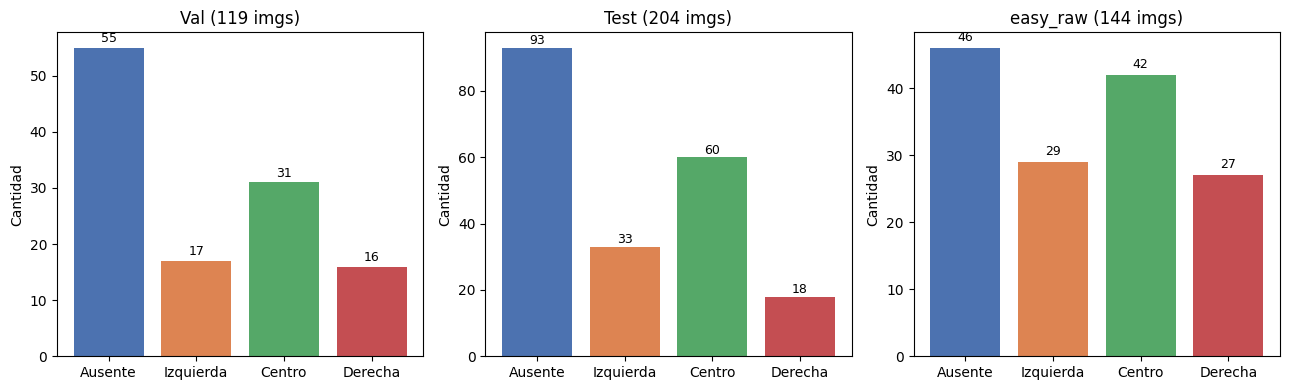

Distribución RAW de train (antes del balance):
  easy     total=144  0= 46 1= 29 2= 42 3= 27  %aus=32%
  medium   total=180  0= 78 1= 41 2= 37 3= 24  %aus=43%
  hard     total=364  0=193 1= 48 2= 88 3= 35  %aus=53%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for ax, (name, y) in zip(axes, [('Val', y_val), ('Test', y_test),
                                   ('easy_raw', y_easy_raw)]):
    counts = np.bincount(y, minlength=NUM_CLASSES)
    bars = ax.bar(CLASS_NAMES, counts, color=colors)
    ax.set_title(f'{name} ({len(y)} imgs)')
    ax.set_ylabel('Cantidad')
    for b, c in zip(bars, counts):
        ax.text(b.get_x() + b.get_width() / 2, c + 1, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Distribución raw de train por dificultad
print('Distribución RAW de train (antes del balance):')
for name, y_r in [('easy', y_easy_raw), ('medium', y_med_raw), ('hard', y_hard_raw)]:
    c = np.bincount(y_r, minlength=NUM_CLASSES)
    print(f'  {name:<8} total={len(y_r):3d}  '
          f'0={c[0]:3d} 1={c[1]:3d} 2={c[2]:3d} 3={c[3]:3d}  '
          f'%aus={c[0]/len(y_r)*100:.0f}%')


In [4]:
def balance_dataset(X, y, target_per_class=180, seed=SEED):
    """Undersamplea la mayoría y oversamplea las minoritarias hasta target_per_class."""
    rng = np.random.default_rng(seed)
    X_out, y_out = [], []
    for c in range(NUM_CLASSES):
        mask = y == c
        X_c = X[mask]
        idx = rng.choice(len(X_c), target_per_class, replace=(len(X_c) < target_per_class))
        X_out.append(X_c[idx])
        y_out.append(np.full(target_per_class, c, dtype=np.int32))
    X_out, y_out = np.concatenate(X_out), np.concatenate(y_out)
    perm = rng.permutation(len(X_out))
    return X_out[perm], y_out[perm]

TARGET = 180  # por clase por dificultad → 720 imgs por dificultad
X_easy_b, y_easy_b = balance_dataset(X_easy_raw, y_easy_raw, target_per_class=TARGET)
X_med_b,  y_med_b  = balance_dataset(X_med_raw,  y_med_raw,  target_per_class=TARGET)
X_hard_b, y_hard_b = balance_dataset(X_hard_raw, y_hard_raw, target_per_class=TARGET)

n = TARGET * NUM_CLASSES  # 720

# 6 fases del curriculum (fracciones de cada dificultad balanceada)
ph1_X, ph1_y = X_easy_b[:n//2],    y_easy_b[:n//2]      # easy   [0-50%]  → 360 imgs
ph2_X, ph2_y = X_med_b[:int(n*.7)], y_med_b[:int(n*.7)] # medium [0-70%]  → 504 imgs
ph3_X, ph3_y = X_hard_b[:int(n*.3)], y_hard_b[:int(n*.3)]# hard  [0-30%]  → 216 imgs
ph4_X, ph4_y = X_easy_b[n//2:],    y_easy_b[n//2:]      # easy   [50-100%]→ 360 imgs
ph5_X, ph5_y = X_med_b[int(n*.7):], y_med_b[int(n*.7):] # medium [70-100%]→ 216 imgs
ph6_X, ph6_y = X_hard_b[int(n*.3):], y_hard_b[int(n*.3):]# hard  [30-100%]→ 504 imgs

print(f'Balanceo: {TARGET} por clase = {n} imgs por dificultad')
print(f'{"Fase":<5} {"descripción":<25} {"imgs":>5}')
print('-' * 38)
for i, (desc, X_p) in enumerate([
    ('easy [0-50%]',    ph1_X), ('medium [0-70%]',   ph2_X),
    ('hard [0-30%]',   ph3_X), ('easy [50-100%]',   ph4_X),
    ('medium [70-100%]',ph5_X), ('hard [30-100%]',  ph6_X),
], 1):
    print(f'  F{i}   {desc:<25} {len(X_p):>5}')


Balanceo: 180 por clase = 720 imgs por dificultad
Fase  descripción                imgs
--------------------------------------
  F1   easy [0-50%]                360
  F2   medium [0-70%]              503
  F3   hard [0-30%]                216
  F4   easy [50-100%]              360
  F5   medium [70-100%]            217
  F6   hard [30-100%]              504


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

@tf.function
def augment(x, y):
    crop = tf.random.uniform((), minval=int(0.82 * IMG_SIZE), maxval=IMG_SIZE, dtype=tf.int32)
    x = tf.image.random_crop(x, [crop, crop, 1])
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    x = tf.image.random_brightness(x, max_delta=0.15)
    x = tf.image.random_contrast(x, lower=0.75, upper=1.25)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

def make_ds(X, y, shuffle=False, aug=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    if aug:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Datasets de validación y test (fijos)
val_ds  = make_ds(X_val,  y_val)
test_ds = make_ds(X_test, y_test)

# Test por dificultad (para benchmarking individual)
easy_test_ds  = make_ds(X_easy_test,  y_easy_test)
med_test_ds   = make_ds(X_med_test,   y_med_test)
hard_test_ds  = make_ds(X_hard_test,  y_hard_test)
other_test_ds = make_ds(X_other_test, y_other_test)

print('Datasets listos')


Datasets listos


I0000 00:00:1780358348.175084  210505 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5269 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [6]:
def build_teacher(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    reg = keras.regularizers.l2(1e-4)  # Reducido: 5e-4 era demasiado agresivo
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters in [64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                          kernel_regularizer=reg)(x)
        x = layers.BatchNormalization(momentum=0.9)(x)
        x = layers.ReLU()(x)
        x = layers.MaxPool2D()(x)            # 128 → 64 → 32 → 16
    for filters in [256, 256]:               # Dos bloques extra a resolución 16x16
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                          kernel_regularizer=reg)(x)
        x = layers.BatchNormalization(momentum=0.9)(x)
        x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(0.3)(x)              # Reducido: 0.5 era demasiado
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='teacher')

teacher = build_teacher()
teacher.summary()
print(f'\nParámetros: {teacher.count_params():,}')
print(f'Tamaño float32: ~{teacher.count_params() * 4 / 1024:.0f} KB')


Model: "teacher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 1,586,116 (6.05 MB)

 Trainable params: 1,584,196 (6.04 MB)

 Non-trainable params: 1,920 (7.50 KB)


Parámetros: 1,586,116
Tamaño float32: ~6196 KB


In [7]:
# Fases cumulativas: cada fase INCLUYE todo lo anterior + datos nuevos
# Evita catastrophic forgetting que destruyó el entrenamiento anterior
cum1_X, cum1_y = ph1_X, ph1_y
cum2_X = np.concatenate([ph1_X, ph2_X]); cum2_y = np.concatenate([ph1_y, ph2_y])
cum3_X = np.concatenate([ph1_X, ph2_X, ph3_X]); cum3_y = np.concatenate([ph1_y, ph2_y, ph3_y])
cum4_X = np.concatenate([cum3_X, ph4_X]); cum4_y = np.concatenate([cum3_y, ph4_y])
cum5_X = np.concatenate([cum4_X, ph5_X]); cum5_y = np.concatenate([cum4_y, ph5_y])
cum6_X = np.concatenate([cum5_X, ph6_X]); cum6_y = np.concatenate([cum5_y, ph6_y])

teacher.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

rlr  = keras.callbacks.ReduceLROnPlateau(
    factor=0.5, patience=8, min_lr=1e-6, monitor='val_loss', verbose=1)
ckpt = keras.callbacks.ModelCheckpoint(
    'teacher_best.keras', save_best_only=True, monitor='val_accuracy', verbose=1)

EPH = 40

phases = [
    (cum1_X, cum1_y, 5e-4, 'F1: easy[0-50%]'),
    (cum2_X, cum2_y, 4e-4, 'F2: +medium[0-70%]'),
    (cum3_X, cum3_y, 3e-4, 'F3: +hard[0-30%]'),
    (cum4_X, cum4_y, 2e-4, 'F4: +easy[50-100%]'),
    (cum5_X, cum5_y, 1e-4, 'F5: +medium[70-100%]'),
    (cum6_X, cum6_y, 5e-5, 'F6: +hard[30-100%]'),
]

histories = []
for X_p, y_p, lr, name in phases:
    teacher.optimizer.learning_rate.assign(lr)
    n_batches = int(np.ceil(len(X_p) / BATCH_SIZE))
    print(f'\n=== {name} ({len(X_p)} imgs, {n_batches} batches/epoch, LR={lr}) ===')
    h = teacher.fit(
        make_ds(X_p, y_p, shuffle=True, aug=True),
        epochs=EPH,
        validation_data=val_ds,
        callbacks=[rlr, ckpt],
    )
    histories.append(h)
    _, acc_val = teacher.evaluate(val_ds, verbose=0)
    print(f'  Val accuracy al terminar {name}: {acc_val*100:.1f}%')



=== F1: easy[0-50%] (360 imgs, 12 batches/epoch, LR=0.0005) ===
Epoch 1/40


I0000 00:00:1780358361.904025  214556 service.cc:153] XLA service 0x7ede60018260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780358361.904044  214556 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780358361.987185  214556 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780358362.307045  214556 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780358362.366236  214556 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4520__.76
I0000 00:00:1780358365.567659  214556 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 1/12 ━━━━━━━━━━━━━━━━━━━━ 2:01 11s/step - accuracy: 0.1875 - loss: 1.7203

I0000 00:00:1780358371.268947  214556 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3318 - loss: 1.4990

...

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8596 - loss: 0.5599
Epoch 1: val_accuracy did not improve from 0.73109
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 227ms/step - accuracy: 0.8517 - loss: 0.5318 - val_accuracy: 0.5462 - val_loss: 1.3155 - learning_rate: 3.0000e-04
Epoch 2/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8678 - loss: 0.4504
Epoch 2: val_accuracy did not improve from 0.73109
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8712 - loss: 0.4584 - val_accuracy: 0.3782 - val_loss: 1.6087 - learning_rate: 3.0000e-04
Epoch 3/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8970 - loss: 0.3864
Epoch 3: val_accuracy did not improve from 0.73109
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8860 - loss: 0.3937 - val_accuracy: 0.3782 - val_loss: 3.7272 - learning_rate: 3.0000e-04
Epoch 4/40
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9009 - loss: 0.3468
Epoch 4: val_accuracy did not improve from 0.73109
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44m

I0000 00:00:1780358608.495577  214554 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4520__.76


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9936 - loss: 0.1043
Epoch 1: val_accuracy did not improve from 0.76471
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.9879 - loss: 0.1157 - val_accuracy: 0.6050 - val_loss: 1.2891 - learning_rate: 1.0000e-04
Epoch 2/40
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9911 - loss: 0.1199
Epoch 2: val_accuracy did not improve from 0.76471
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9873 - loss: 0.1219 - val_accuracy: 0.4706 - val_loss: 2.0111 - learning_rate: 1.0000e-04
Epoch 3/40
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9842 - loss: 0.1283
Epoch 3: val_accuracy did not improve from 0.76471
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9831 - loss: 0.1299 - val_accuracy: 0.4958 - val_loss: 2.1228 - learning_rate: 1.0000e-04
Epoch 4/40
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9901 - loss: 0.1139
Epoch 4: val_accuracy did not improve from 0.76471
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42

I0000 00:00:1780358706.028027  214555 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4520__.76


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9392 - loss: 0.2788
Epoch 1: val_accuracy did not improve from 0.76471
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.9398 - loss: 0.2735 - val_accuracy: 0.6891 - val_loss: 1.1482 - learning_rate: 5.0000e-05
Epoch 2/40
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9504 - loss: 0.2246
Epoch 2: val_accuracy did not improve from 0.76471
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9468 - loss: 0.2329 - val_accuracy: 0.7143 - val_loss: 1.2372 - learning_rate: 5.0000e-05
Epoch 3/40
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9600 - loss: 0.1934
Epoch 3: val_accuracy did not improve from 0.76471
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9551 - loss: 0.2040 - val_accuracy: 0.7143 - val_loss: 1.0171 - learning_rate: 5.0000e-05
Epoch 4/40
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9684 - loss: 0.1784
Epoch 4: val_accuracy did not improve from 0.76471
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 42

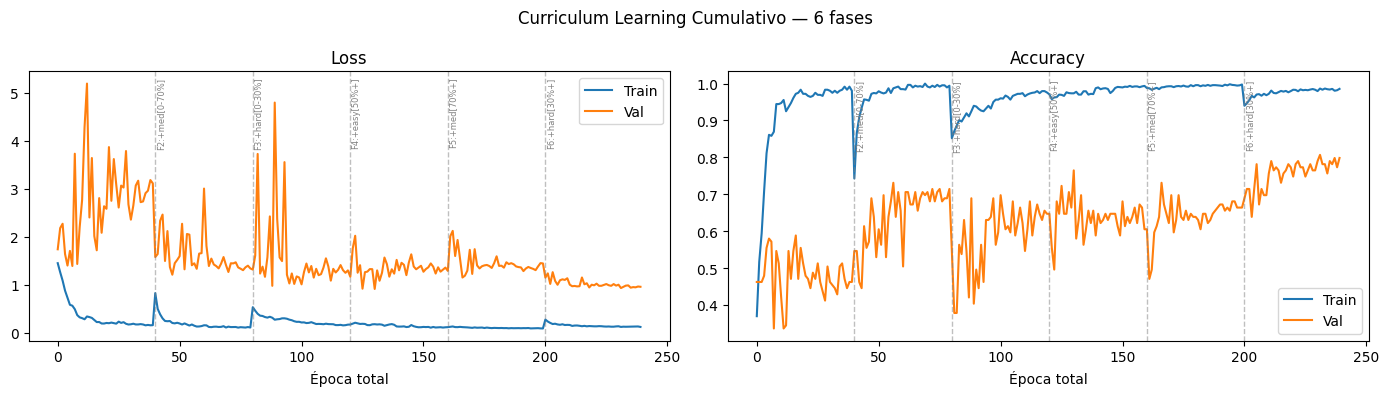

In [8]:
def cat(key, hists):
    return [v for h in hists for v in h.history[key]]

phase_labels = ['F1:easy[0-50%]', 'F2:+med[0-70%]', 'F3:+hard[0-30%]',
                'F4:+easy[50%+]', 'F5:+med[70%+]', 'F6:+hard[30%+]']
boundaries = list(np.cumsum([len(h.history['loss']) for h in histories[:-1]]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, title in [(ax1, 'loss', 'Loss'), (ax2, 'accuracy', 'Accuracy')]:
    ax.plot(cat(key, histories),          label='Train')
    ax.plot(cat(f'val_{key}', histories), label='Val')
    for b, label in zip(boundaries, phase_labels[1:]):
        ax.axvline(b, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(b + 0.3, ax.get_ylim()[1] * 0.98, label,
                fontsize=6, rotation=90, va='top', color='gray')
    ax.set_title(title); ax.set_xlabel('Época total'); ax.legend()
plt.suptitle('Curriculum Learning Cumulativo — 6 fases')
plt.tight_layout()
plt.show()


In [9]:
# Cargar el mejor modelo guardado durante el curriculum
teacher = keras.models.load_model('teacher_best.keras')
print('Mejor teacher cargado desde teacher_best.keras\n')

print('=== Accuracy por dificultad ===')
results = {}
for name, ds, y_d in [
    ('easy',   easy_test_ds,  y_easy_test),
    ('medium', med_test_ds,   y_med_test),
    ('hard',   hard_test_ds,  y_hard_test),
    ('other',  other_test_ds, y_other_test),
    ('TOTAL',  test_ds,       y_test),
]:
    _, acc = teacher.evaluate(ds, verbose=0)
    results[name] = acc
    bar = '█' * int(acc * 20)
    print(f'  {name:<8} {acc*100:>5.1f}%  {bar}  (n={len(y_d)})')


Mejor teacher cargado desde teacher_best.keras

=== Accuracy por dificultad ===
  easy     100.0%  ████████████████████  (n=19)
  medium    91.3%  ██████████████████  (n=23)
  hard      69.6%  █████████████  (n=79)
  other     44.6%  ████████  (n=83)
  TOTAL     64.7%  ████████████  (n=204)


In [10]:
loss, acc = teacher.evaluate(test_ds, verbose=0)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {acc:.4f}  ({acc * 100:.1f}%)')

Test Loss:     1.6196
Test Accuracy: 0.6471  (64.7%)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


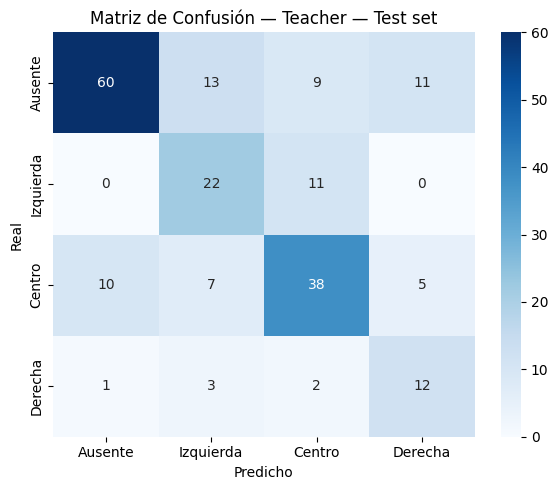

              precision    recall  f1-score   support

     Ausente       0.85      0.65      0.73        93
   Izquierda       0.49      0.67      0.56        33
      Centro       0.63      0.63      0.63        60
     Derecha       0.43      0.67      0.52        18

    accuracy                           0.65       204
   macro avg       0.60      0.65      0.61       204
weighted avg       0.69      0.65      0.66       204



In [11]:
y_pred = np.argmax(teacher.predict(test_ds), axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Teacher — Test set')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

### 7.3 Ejemplos con entradas y salidas

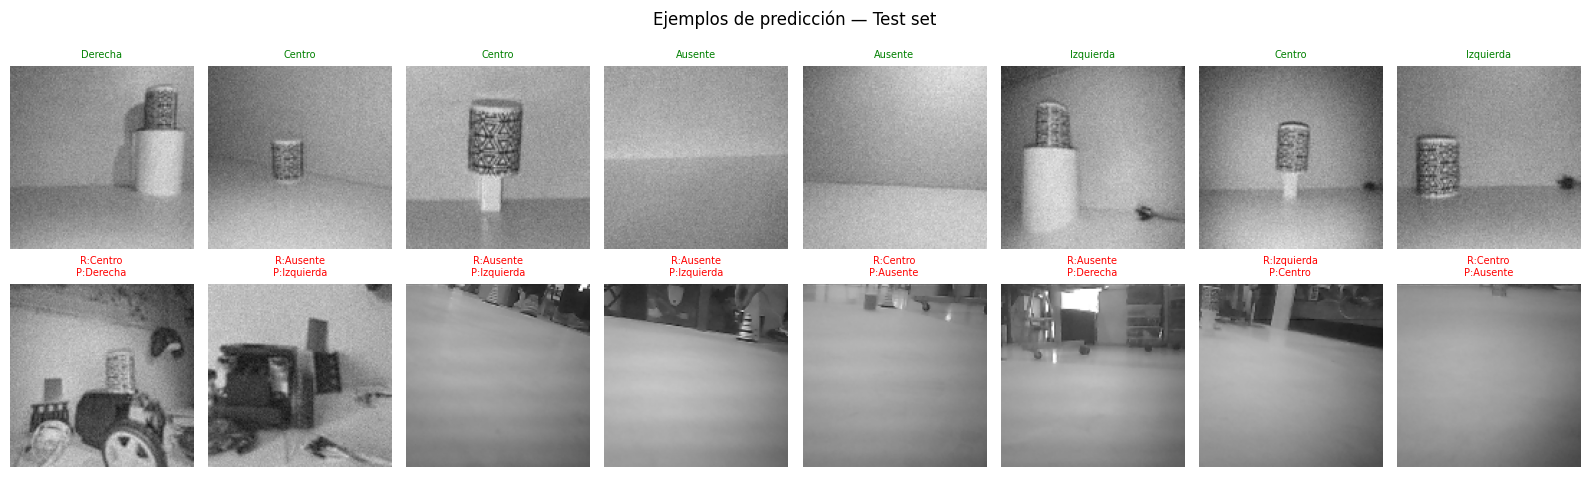

In [14]:
n_show = 8
correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
for row, (idxs, row_label, color) in enumerate([
    (correct_idx,   'Correctas',   'green'),
    (incorrect_idx, 'Incorrectas', 'red'),
]):
    for col in range(n_show):
        ax = axes[row, col]
        if col < len(idxs):
            idx = idxs[col]
            ax.imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            real = CLASS_NAMES[y_test[idx]]
            pred = CLASS_NAMES[y_pred[idx]]
            title = real if row == 0 else f'R:{real}\nP:{pred}'
            ax.set_title(title, fontsize=7, color=color)
        ax.axis('off')
    axes[row, 0].set_ylabel(row_label, fontsize=9)
plt.suptitle('Ejemplos de predicción — Test set')
plt.tight_layout()
plt.show()

## 8. Guardar modelo

In [15]:
teacher.save('teacher_final.keras')
teacher.save_weights('teacher_weights.weights.h5')
print('Guardado: teacher_final.keras + teacher_weights.weights.h5')
print(f'Parámetros: {teacher.count_params():,}')
print(f'Tamaño (float32): ~{teacher.count_params() * 4 / 1024:.0f} KB')

Guardado: teacher_final.keras + teacher_weights.weights.h5
Parámetros: 1,586,116
Tamaño (float32): ~6196 KB
